In [2]:
library(ggplot2)
library(readxl)
library(dplyr)
library(tibble)
library(reshape2)

In [ ]:
sfo_data <- read_excel("Phil_Copple.xlsx")
head(sfo_data)

In [64]:
# Make First Colomn the rowname to facilate transposing the dataframe
sfo_data2 <- column_to_rownames(sfo_data, var = "Description")
head(sfo_data2)

,2010/11,2011/12,2012/13,2013/14,2014/15,2015/16,2016/17,2017/18,2018/19,2019/20,2020/21,2021/22,2022/23
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Notifications,473,466,489,507,477,558,685,678,577,536,498,528,578
Reviews,430,413,449,447,424,490,593,568,502,480,456,448,286
Convictions,257,253,270,274,254,301,348,357,346,316,250,229,118
Murder,50,67,51,59,46,41,57,81,103,87,57,46,27
Attempted murder/ Conspiracy to commit murder,12,13,16,15,14,24,15,20,30,20,19,12,2
Manslaughter,18,15,16,23,12,16,34,32,34,30,28,15,7


In [65]:
# transpose the dataframe, keeping it as a dataframe

sfo_data2 <- data.frame(t(sfo_data2))
head(sfo_data2)

,Notifications,Reviews,Convictions,Murder,Attempted.murder..Conspiracy.to.commit.murder,Manslaughter,Rape..Assault.by.penetration..Assault.by.penetration.on.a.child.under.13..Attempted.Rape..Rape.of.a.under.13,Arson.with.intent.to.endanger.life,Kidnapping..Abduction.False.imprisonment,Death.involving.driving.or.vehicle.taking,Other.serious.sexual.violent.offences,Outstanding
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
2010/11,473,430,257,50,12,18,101,8,2,8,58,0
2011/12,466,413,253,67,13,15,77,8,14,6,53,0
2012/13,489,449,270,51,16,16,93,7,16,5,66,0
2013/14,507,447,274,59,15,23,80,10,19,8,60,0
2014/15,477,424,254,46,14,12,89,9,21,5,58,0
2015/16,558,490,301,41,24,16,107,12,9,9,83,0


In [66]:
# Create a Year column taking the values of the new rowname values

sfo_data2$Year <- row.names(sfo_data2)  
head(sfo_data2)

,Notifications,Reviews,Convictions,Murder,Attempted.murder..Conspiracy.to.commit.murder,Manslaughter,Rape..Assault.by.penetration..Assault.by.penetration.on.a.child.under.13..Attempted.Rape..Rape.of.a.under.13,Arson.with.intent.to.endanger.life,Kidnapping..Abduction.False.imprisonment,Death.involving.driving.or.vehicle.taking,Other.serious.sexual.violent.offences,Outstanding,Year
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
2010/11,473,430,257,50,12,18,101,8,2,8,58,0,2010/11
2011/12,466,413,253,67,13,15,77,8,14,6,53,0,2011/12
2012/13,489,449,270,51,16,16,93,7,16,5,66,0,2012/13
2013/14,507,447,274,59,15,23,80,10,19,8,60,0,2013/14
2014/15,477,424,254,46,14,12,89,9,21,5,58,0,2014/15
2015/16,558,490,301,41,24,16,107,12,9,9,83,0,2015/16


In [67]:
# Keep needed variables in the order you want it and drop rownames

sfo_data2 <- sfo_data2[,c("Year","Notifications","Reviews","Convictions")]
rownames(sfo_data2) <- NULL
sfo_data2

Year,Notifications,Reviews,Convictions
<chr>,<dbl>,<dbl>,<dbl>
2010/11,473,430,257
2011/12,466,413,253
2012/13,489,449,270
2013/14,507,447,274
2014/15,477,424,254
2015/16,558,490,301
2016/17,685,593,348
2017/18,678,568,357
2018/19,577,502,346


In [72]:
sfo_data2 <- sfo_data2

sfo_data2$Nots_published <- c(sfo_data2$Notifications[1:12],NA)
sfo_data2$Revs_published <- c(rep(NA,3),sfo_data2$Reviews[4:12],NA)
sfo_data2$Convs_published <- c(sfo_data2$Convictions[1:10],rep(NA,3))

sfo_data2$Nots_unpublished <- c(rep(NA,11),sfo_data2$Notifications[12:13])
sfo_data2$Revs_unpublished <- c(sfo_data2$Reviews[1:4],rep(NA,7),sfo_data2$Reviews[12:13])
sfo_data2$Convs_unpublished <- c(rep(NA,9),sfo_data2$Convictions[10:13])
sfo_data2

Year,Notifications,Reviews,Convictions,Nots_published,Revs_published,Convs_published,Nots_unpublished,Revs_unpublished,Convs_unpublished,year_dummy
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>
2010/11,473,430,257,473,NA,257,NA,430,NA,1
2011/12,466,413,253,466,NA,253,NA,413,NA,2
2012/13,489,449,270,489,NA,270,NA,449,NA,3
2013/14,507,447,274,507,447,274,NA,447,NA,4
2014/15,477,424,254,477,424,254,NA,NA,NA,5
2015/16,558,490,301,558,490,301,NA,NA,NA,6
2016/17,685,593,348,685,593,348,NA,NA,NA,7
2017/18,678,568,357,678,568,357,NA,NA,NA,8
2018/19,577,502,346,577,502,346,NA,NA,NA,9


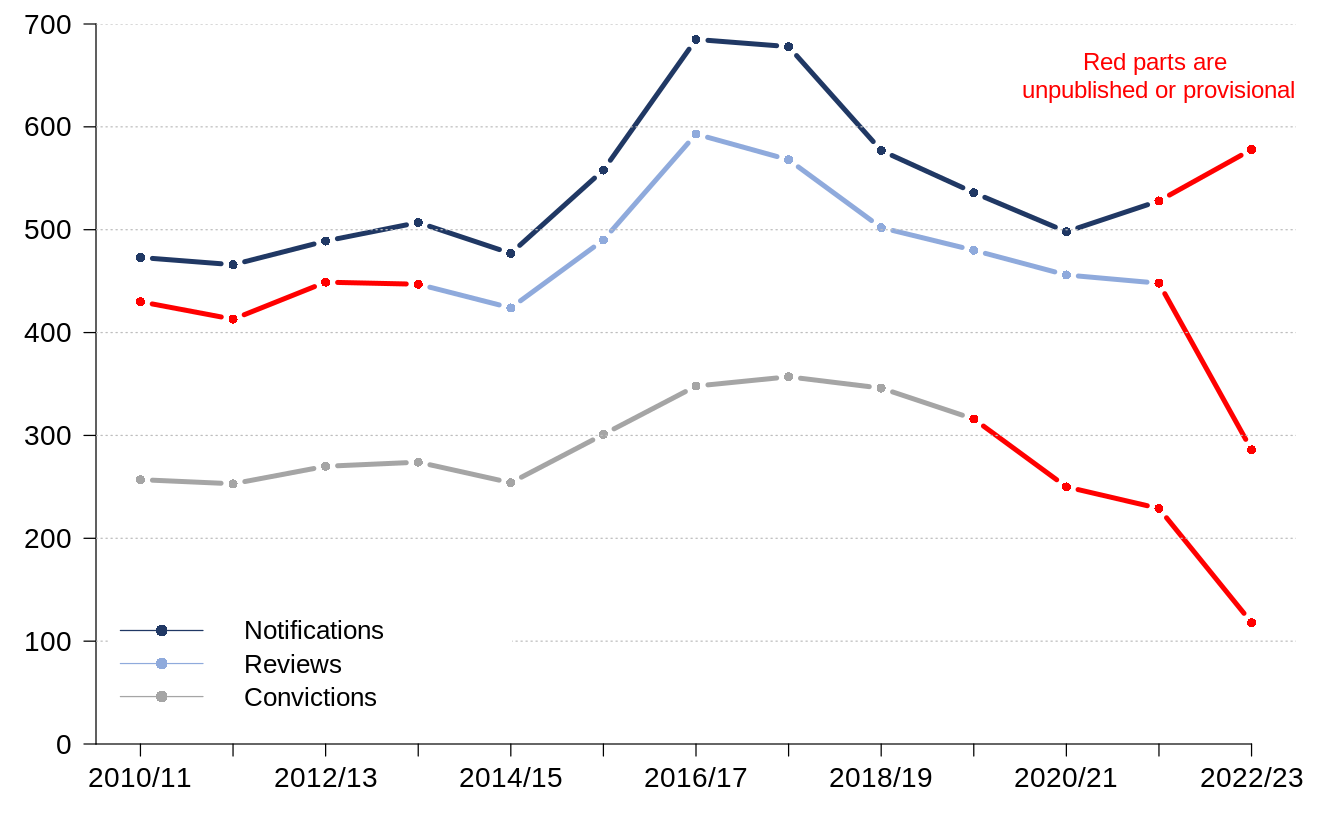

In [93]:
sfo_data2$year_dummy <- 1:nrow(sfo_data2)

options(repr.plot.width = 11, repr.plot.height = 7)

par(mar = c(4, 4, 1, 1))  

plot(Nots_published ~ year_dummy,data=sfo_data2, type='b', col="#203864",
     ylim=c(0,700),
     ylab ="",
     xlab="",
     xaxt="n",
     yaxt="n",
     axes=FALSE,
     bty="L",
     yaxs="i",lwd=4,pch=16)
lines(Revs_published ~ year_dummy,data=sfo_data2, type='b', col="#8FAADC",lwd=4,pch=16)
lines(Convs_published ~ year_dummy,data=sfo_data2, type='b', col="#A5A5A5",lwd=4,pch=16)
lines(Nots_unpublished ~ year_dummy,data=sfo_data2, type='b', col="red",lwd=4,pch=16)
lines(Revs_unpublished ~ year_dummy,data=sfo_data2, type='b', col="red",lwd=4,pch=16)
lines(Convs_unpublished ~ year_dummy,data=sfo_data2, type='b', col="red",lwd=4,pch=16)
#points(Outstanding ~ Year,data=df4, type='b', pch=16,col="#ED7D31",lwd=2)
axis(1,cex.axis=1.4, at=c(0,1:nrow(sfo_data2)),labels = c("",sfo_data2$Year),cex=1)
text(12, 650, "Red parts are \nunpublished or provisional",col="red",cex = 1.2)
axis(2,cex.axis=1.4,las=2,cex=1)
abline(h=seq(100,700,by=100),col="grey",lty="dotted")
legend("bottomleft",legend=c("Notifications","Reviews","Convictions"),
       col=c("#203864", "#8FAADC", "#A5A5A5"),
       box.lty = 0,inset = c(0.01,0.02),cex=1.3,lty = 1,pch=16,ncol = 1)

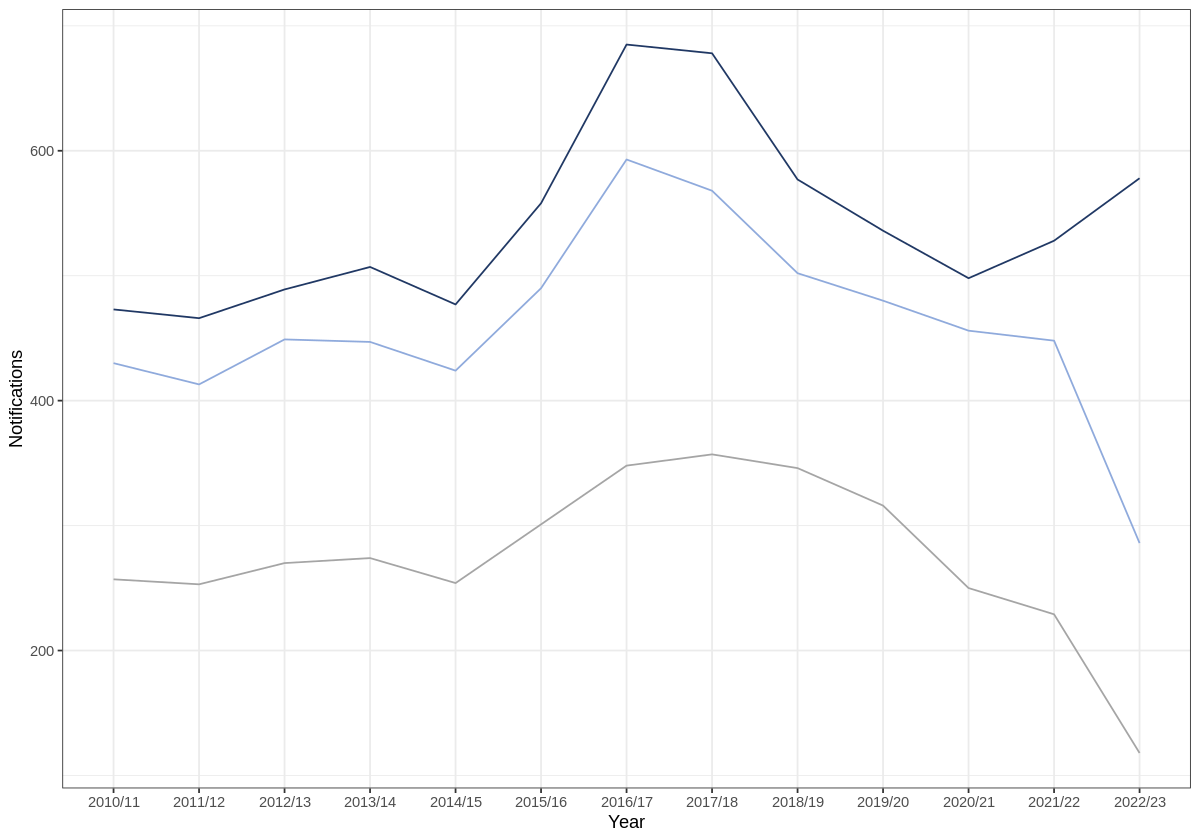

In [27]:
ggplot(sfo_data2, aes(Year, group=1)) +
    geom_line(aes(y = Notifications),color = "#203864") + 
    geom_line(aes(y = Reviews),color = "#8FAADC") + 
    geom_line(aes(y = Convictions),color = "#A5A5A5") +
    theme_bw()

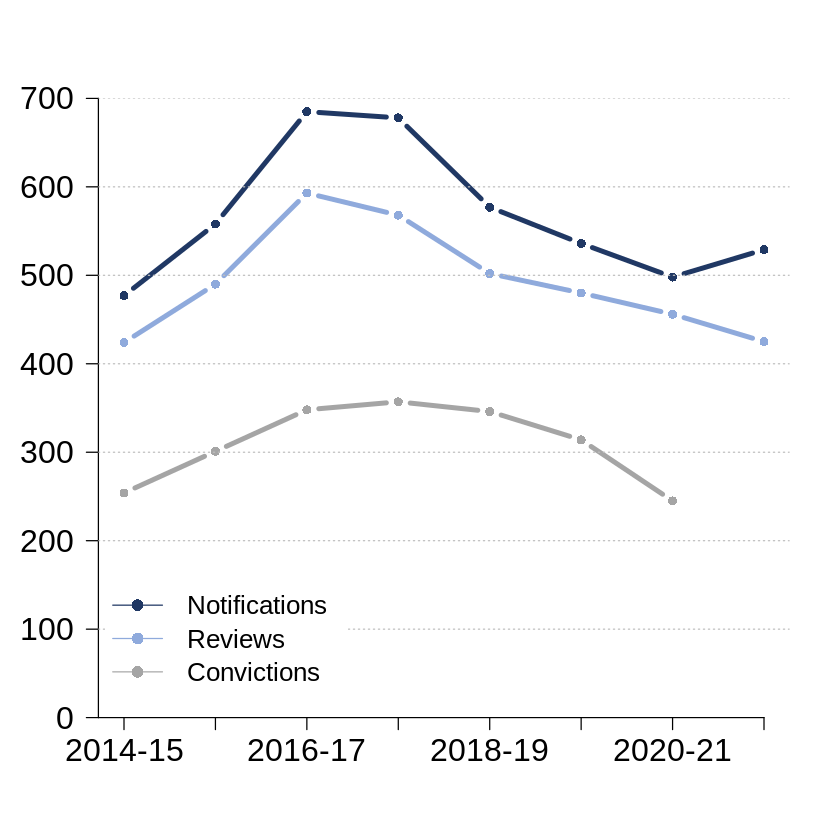

In [15]:
Period2 <- c('2014-15','2015-16','2016-17','2017-18','2018-19','2019-20','2020-21','2021-22')
Notifications <- c(477,558,685,678,577,536,498,529)
Reviews <- c(424,490,593,568,502,480,456,425)
Total <- c(254,301,348,357,346,314,245)
Convictions <- c(Total,NA)
Outstanding <- c(0,0,0,0,0,20,72,NA) 

df4 <- data.frame(Period2,Notifications,Reviews,Convictions,Outstanding)
df4$Year <- c(1,2,3,4,5,6,7,8)


plot(Notifications ~ Year,data=df4, type='b', col="#203864",
     ylim=c(0,700),
     ylab ="",
     xlab="",
     xaxt="n",
     yaxt="n",
     axes=FALSE,
     bty="L",
     yaxs="i",lwd=4,pch=16)
lines(Reviews ~ Year,data=df4, type='b', col="#8FAADC",lwd=4,pch=16)
lines(Convictions ~ Year,data=df4, type='b', col="#A5A5A5",lwd=4,pch=16)
#points(Outstanding ~ Year,data=df4, type='b', pch=16,col="#ED7D31",lwd=2)
axis(1,cex.axis=1.6, at=c(0,1,2,3,4,5,6,7,8),labels = c("",Period2),cex=1)
axis(2,cex.axis=1.6,las=2,cex=1)
abline(h=seq(100,700,by=100),col="grey",lty="dotted")
legend("bottomleft",legend=c("Notifications","Reviews","Convictions"),
       col=c("#203864", "#8FAADC", "#A5A5A5"),
       box.lty = 0,inset = c(0.01,0.02),cex=1.3,lty = 1,pch=16,ncol = 1)


In [ ]:
period <- c('2014-15','2015-16','2016-17','2017-18','2018-19','2019-20','2020-21')
Total <- c(254,301,348,357,346,314,245)
ORA <- c(2,34,75,73,71,68,56)
df <- data.frame(period,Total,ORA)
df$Non_ORA <- (df$Total - df$ORA)
df <- df[,c("period","Total","Non_ORA","ORA")]

Outstanding <- c(0,0,0,0,0,20,72)
variable <- "Total"

df2 <- data.frame(period,variable,Outstanding)
df2 <- df2 %>% rename(value =Outstanding)

df3 <- melt(df,id.vars ='period')
#df3$outstanding <- outstanding

ggplot(df3, aes(x=period)) +
  geom_bar(stat="identity", aes(y=value,fill=variable),position='dodge',color = "black",size=0.2)+
  scale_fill_manual(values=c("#203864","#8FAADC","#DAE3F3"))+
  geom_point(data=df2,aes(y=value,shape="Outstanding Cases"), color ="red")+
  ylim(0,400) +
  labs(shape=NULL) +
  theme_classic()+
  theme(legend.title = element_blank(),
        text = element_text(size = 14),
        axis.title = element_blank(),
        legend.position = "bottom",
        legend.text = element_text(size = 10),
        panel.grid.major.y = element_line(size=0.2,color="grey")) 